# Phase One: Data Loading & Core Integration

## Data Source:
https://huggingface.co/datasets/BrotherTony/employee-burnout-turnover-prediction-800k

## Overview:
The primary goal of this phase is to establish a robust and clean foundation for our predictive study. Given the large scale of the HuggingFace synthetic dataset (~850k records), we performed a Strategic Feature Selection to focus only on variables that have a theoretical and empirical impact on employee burnout. This stage ensures our data is structurally sound, normalized in its naming conventions, and prepared for deep exploratory analysis.

## Key Objectives:
- **Selective Data Ingestion:** Streamlining the dataset by importing only **11** critical features (out of **31**) to optimize memory usage and eliminate noise during the training phase.

- **Target Standardization:** Renaming the primary metric from burnout_risk to burnout_score to align with the project's goal of predicting a continuous burnout magnitude.

- **Data Integrity Verification:** Executing a multi step audit including shape, info, and describe to validate data types and understand the statistical range of behavioral metrics.

- **Cleaning & Quality Assurance:** Conducting a rigorous check for missing values (isnull) and duplicated entries to ensure the model isn't trained on biased or redundant information.

### Imports

In [1]:
!pip install lightgbm

In [2]:
!pip install xgboost

In [3]:
# All imports

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
import xgboost as xgb
import lightgbm as lgb

from sklearn.model_selection import GridSearchCV


<br>
<hr>
<br>

In [4]:
# Loading the data

path = "Data/synthetic-employee-dataset.json"
df_all = pd.read_json(path).head(50000)


In [5]:
df_all.head()

,employee_id,role,job_level,department,tenure_months,salary,performance_score,satisfaction_score,workload_score,team_sentiment,...,goal_achievement_rate,stress_level,burnout_risk,left_company,turnover_reason,risk_factors_summary,turnover_probability_generated,persona_name,role_complexity_score,career_progression_score
0,SYN_00000000,,Mid,Research & Development,169,79704.579059,0.632482,0.623746,0.758117,0.662335,...,0.632482,0.908992,0.866643,False,Not Applicable,Severe Burnout Risk,0.290979,ChangeResistor,0.2,1.000000
1,SYN_00000001,Customer Success Manager,Manager,Research & Development,54,29694.288831,0.538587,0.982556,0.788416,0.934661,...,0.538587,0.363321,0.218996,False,Not Applicable,Low Risk,0.156002,NewEnthusiast,0.2,1.000000
2,SYN_00000002,Administrative Assistant,Entry,HR,1,62208.470185,0.624656,0.767200,0.697617,0.888559,...,0.624656,0.664378,0.541531,True,Personal / Relocation,Low Risk,0.233897,NewEnthusiast,0.2,0.836495
3,SYN_00000003,Senior Manager,Manager,Research & Development,31,236066.567114,0.959320,0.185888,0.493143,0.732189,...,0.959320,1.000000,1.000000,False,Not Applicable,Severe Burnout Risk,0.351682,OverachievingSprinter,0.2,1.000000
4,SYN_00000004,Anonymous Employee,Mid,Research & Development,131,37306.328156,0.677305,0.566706,0.567230,0.817545,...,0.677305,0.723049,0.614825,False,Not Applicable,Low Risk,0.272910,SeasonedExpert,0.2,1.000000


In [6]:
df_all.shape

(50000, 31)

In [7]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   employee_id                     50000 non-null  object 
 1   role                            50000 non-null  object 
 2   job_level                       50000 non-null  object 
 3   department                      50000 non-null  object 
 4   tenure_months                   50000 non-null  int64  
 5   salary                          50000 non-null  float64
 6   performance_score               50000 non-null  float64
 7   satisfaction_score              50000 non-null  float64
 8   workload_score                  50000 non-null  float64
 9   team_sentiment                  50000 non-null  float64
 10  recent_feedback                 50000 non-null  object 
 11  communication_patterns          50000 non-null  object 
 12  project_completion_rate         

In [8]:
# chaeck for missing value
df_all.isnull().sum()

employee_id                       0
role                              0
job_level                         0
department                        0
tenure_months                     0
salary                            0
performance_score                 0
satisfaction_score                0
workload_score                    0
team_sentiment                    0
recent_feedback                   0
communication_patterns            0
project_completion_rate           0
overtime_hours                    0
training_participation            0
collaboration_score               0
technical_skills                  0
soft_skills                       0
email_sentiment                   0
slack_activity                    0
meeting_participation             0
goal_achievement_rate             0
stress_level                      0
burnout_risk                      0
left_company                      0
turnover_reason                   0
risk_factors_summary              0
turnover_probability_generat

In [9]:
# Checking for missing duplicates
cols_to_check = [col for col in df_all.columns if df_all[col].apply(lambda x: not isinstance(x, list)).all()]
duplicates_count = df_all.duplicated(subset=cols_to_check).sum()

duplicates_count

np.int64(0)

In [10]:

df_all.describe()

,tenure_months,salary,performance_score,satisfaction_score,workload_score,team_sentiment,project_completion_rate,overtime_hours,training_participation,collaboration_score,email_sentiment,slack_activity,meeting_participation,goal_achievement_rate,stress_level,burnout_risk,turnover_probability_generated,role_complexity_score,career_progression_score
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,70.397220,84748.181253,0.691892,0.582013,0.599002,0.665998,0.595452,3.134798,0.279154,0.472833,0.582455,0.472833,0.472833,0.691892,0.790308,0.735088,0.285236,0.210669,0.840743
std,49.954227,47607.320582,0.184263,0.276715,0.199841,0.178386,0.162002,6.109558,0.221270,0.185048,0.277646,0.185048,0.185048,0.184263,0.264962,0.316013,0.088065,0.084221,0.182659
min,1.000000,27746.801996,0.089174,0.050000,0.006741,0.037094,0.071339,0.000000,0.000205,0.031474,0.042500,0.031474,0.031474,0.089174,0.000000,0.000000,0.131127,0.200000,0.227075
25%,30.000000,41191.652214,0.569779,0.366392,0.455830,0.544799,0.489588,0.000000,0.104231,0.332088,0.367429,0.332088,0.332088,0.569779,0.614435,0.481631,0.227842,0.200000,0.713163
50%,67.000000,78058.040331,0.699483,0.584626,0.612435,0.685244,0.610424,0.000000,0.223557,0.456690,0.584475,0.456690,0.456690,0.699483,0.939421,0.910522,0.299044,0.200000,0.911626
75%,105.000000,116602.612442,0.826338,0.813276,0.756232,0.805999,0.716413,4.196352,0.399233,0.599783,0.811351,0.599783,0.599783,0.826338,1.000000,1.000000,0.335296,0.200000,1.000000
max,274.000000,352400.848997,1.000000,1.000000,0.998403,0.999468,1.000000,70.973157,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.899874,1.000000,1.000000


# Phese Two: Exploratory Data Analysis (EDA)



## Overview:
The goal of this phase is to visually investigate the patterns and correlations within our optimized dataset. By utilizing statistical plots, we aim to validate our feature engineering decisions and identify the strongest drivers of employee burnout. This stage provides the "Why" behind the numbers before we move to the predictive modeling phase.

## Quick Information (from dataset website):
- Total Records 800,000+
- Departments 38 unique divisions
- Job Roles 300+ distinct positions
- Employee Personas 12 behavioral archetypes
- Features per Record 30+ attributes
- Salary Range 27k -384K


In [11]:

# Improving the appearance of the graphics
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

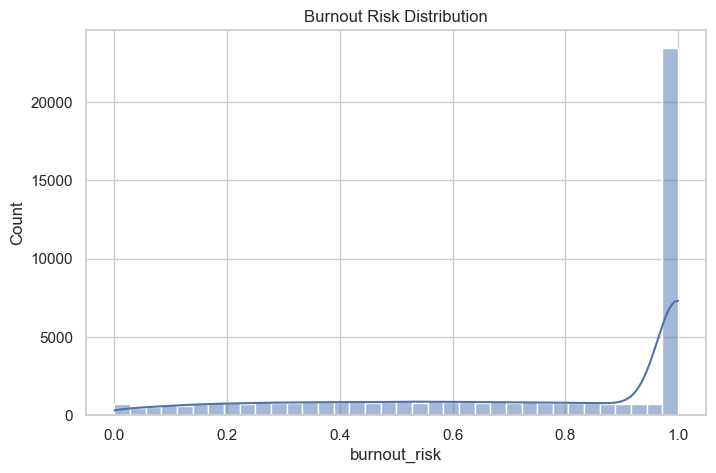

In [12]:
plt.figure()
sns.histplot(df_all["burnout_risk"], kde=True)
plt.title("Burnout Risk Distribution")
plt.xlabel("burnout_risk")
plt.ylabel("Count")
plt.show()

> #### A noticeable concentration of higher burnout values suggests that a considerable number of employees may be experiencing elevated work-related strain.




---

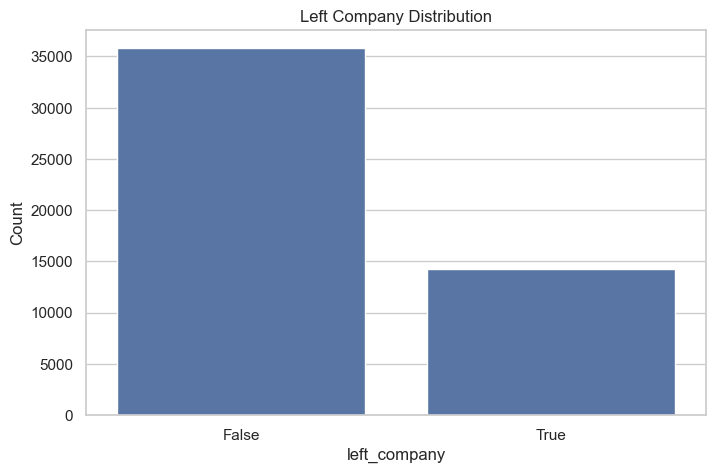

In [13]:
plt.figure()
sns.countplot(x="left_company", data=df_all)
plt.title("Left Company Distribution")
plt.xlabel("left_company")
plt.ylabel("Count")
plt.show()

In [14]:
numeric_cols = [
    'tenure_months',
    'salary',
    'performance_score',
    'satisfaction_score',
    'workload_score',
    'team_sentiment',
    'project_completion_rate',
    'overtime_hours',
    'training_participation',
    'collaboration_score',
    'email_sentiment',
    'slack_activity',
    'meeting_participation',
    'goal_achievement_rate',
    'stress_level',
    'burnout_risk',
    'role_complexity_score',
    'career_progression_score'
]


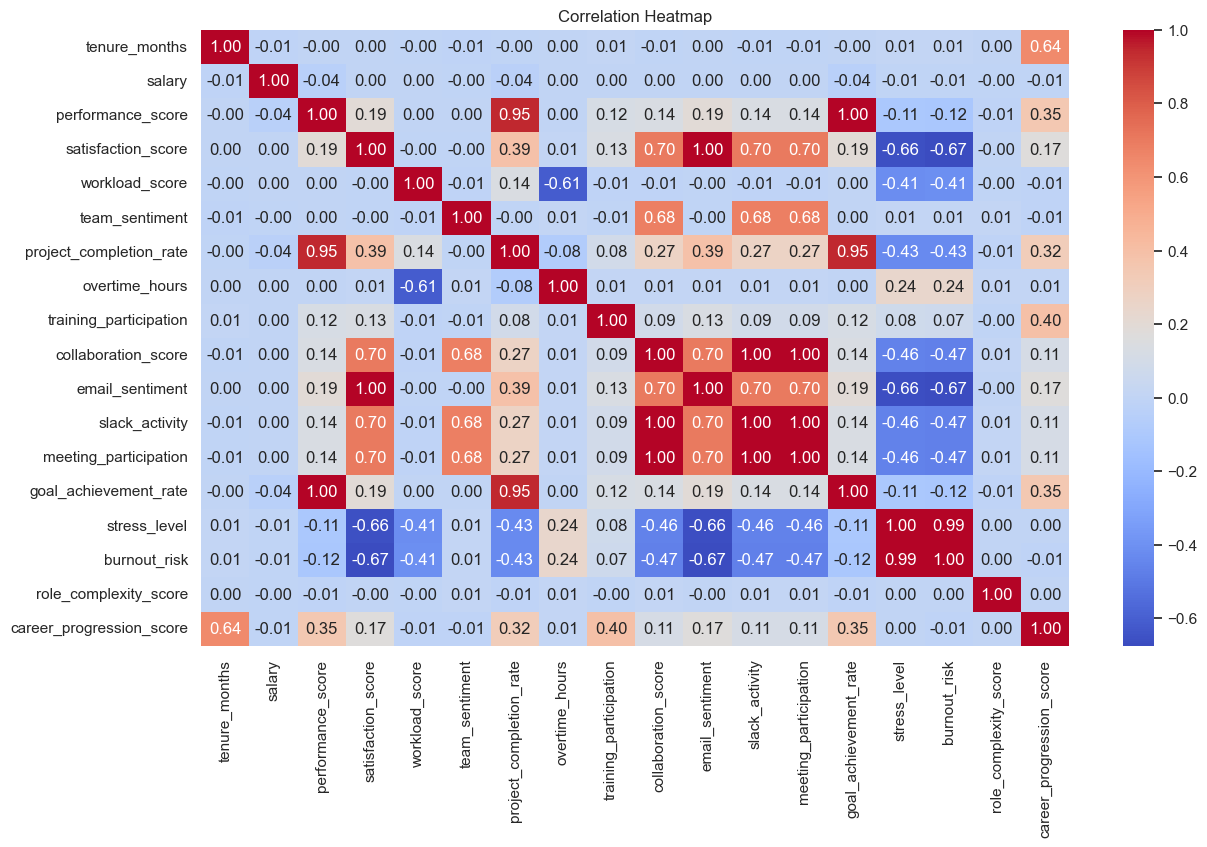

In [15]:
corr = df_all[numeric_cols].corr()

plt.figure(figsize=(14, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


>#### The correlation heatmap provides an overall view of how numeric variables relate to each other, helping identify strong positive or negative relationships.

In [16]:
burnout_features = [
    'tenure_months',
    'salary',
    'performance_score',
    'satisfaction_score',
    'workload_score',
    'team_sentiment',
    'project_completion_rate',
    'overtime_hours',
    'training_participation',
    'collaboration_score',
    'email_sentiment',
    'slack_activity',
    'meeting_participation',
    'goal_achievement_rate',
    'stress_level',
    'role_complexity_score',
    'career_progression_score'
]

burnout_corr = df_all[burnout_features + ['burnout_risk']].corr()['burnout_risk'].sort_values(ascending=False)

print("\nCorrelation with Burnout Risk:")
print(burnout_corr)

print("\nTop Positive Factors Increasing Burnout:")
print(burnout_corr[burnout_corr > 0].sort_values(ascending=False))

print("\nTop Negative Factors Reducing Burnout:")
print(burnout_corr[burnout_corr < 0].sort_values())


Correlation with Burnout Risk:
burnout_risk                1.000000
stress_level                0.994146
overtime_hours              0.237969
training_participation      0.068780
team_sentiment              0.006272
tenure_months               0.006136
role_complexity_score       0.003778
salary                     -0.005172
career_progression_score   -0.008173
performance_score          -0.117730
goal_achievement_rate      -0.117730
workload_score             -0.407909
project_completion_rate    -0.432321
collaboration_score        -0.467859
meeting_participation      -0.467859
slack_activity             -0.467859
satisfaction_score         -0.673671
email_sentiment            -0.674676
Name: burnout_risk, dtype: float64

Top Positive Factors Increasing Burnout:
burnout_risk              1.000000
stress_level              0.994146
overtime_hours            0.237969
training_participation    0.068780
team_sentiment            0.006272
tenure_months             0.006136
role_complexity

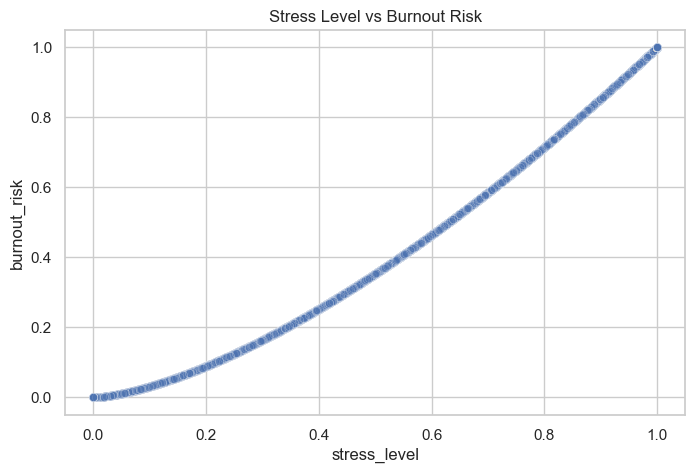

In [17]:
plt.figure()
sns.scatterplot(x="stress_level", y="burnout_risk", data=df_all, alpha=0.3)
plt.title("Stress Level vs Burnout Risk")
plt.show()

>#### Stress level appears to be one of the strongest positive indicators of burnout risk.

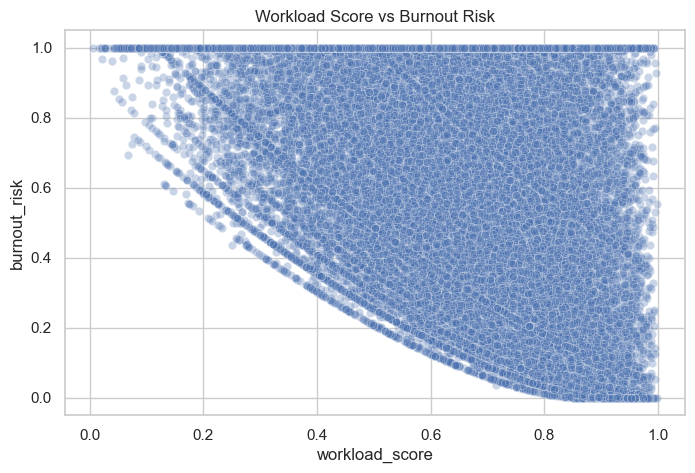

In [18]:
plt.figure()
sns.scatterplot(x="workload_score", y="burnout_risk", data=df_all, alpha=0.3)
plt.title("Workload Score vs Burnout Risk")
plt.show()

>#### A higher workload score is strongly associated with increased burnout risk.

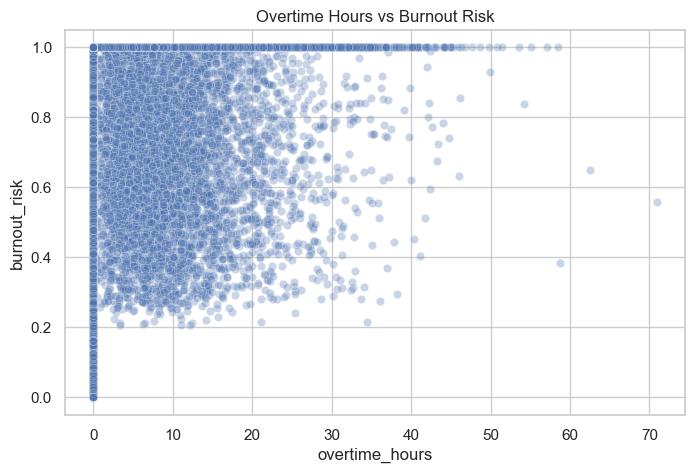

In [19]:
plt.figure()
sns.scatterplot(x="overtime_hours", y="burnout_risk", data=df_all, alpha=0.3)
plt.title("Overtime Hours vs Burnout Risk")
plt.show()

>#### Employees with more overtime hours tend to have higher burnout risk.

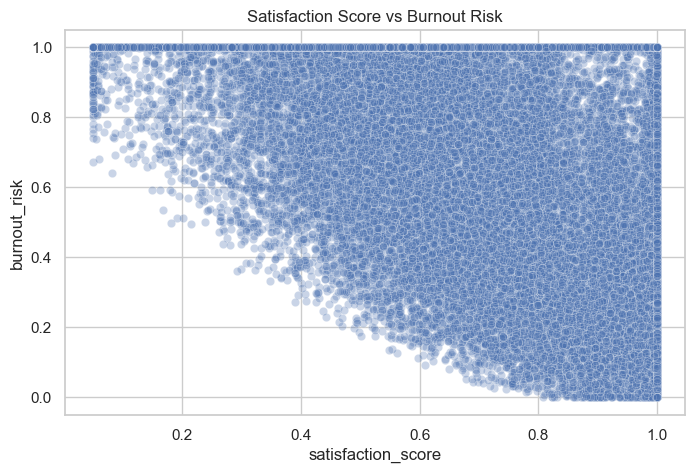

In [20]:
plt.figure()
sns.scatterplot(x="satisfaction_score", y="burnout_risk", data=df_all, alpha=0.3)
plt.title("Satisfaction Score vs Burnout Risk")
plt.show()

>#### Higher job satisfaction is associated with lower burnout risk.

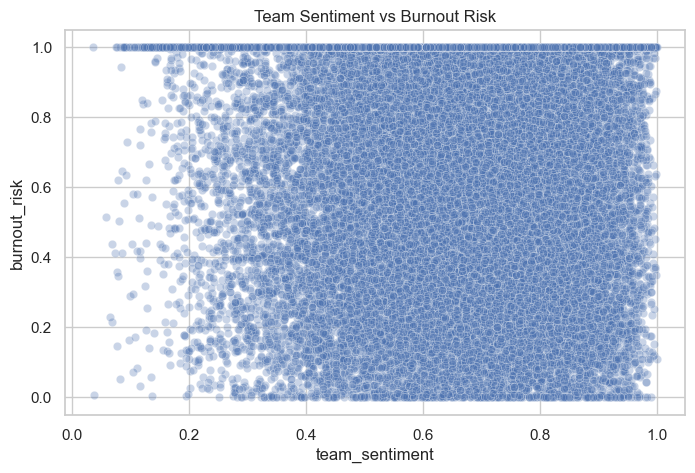

In [21]:
plt.figure()
sns.scatterplot(x="team_sentiment", y="burnout_risk", data=df_all, alpha=0.3)
plt.title("Team Sentiment vs Burnout Risk")
plt.show()

>#### A more positive team environment is linked to lower burnout levels.

In [22]:
df_all["left_company_num"] = df_all["left_company"].astype(int)

turnover_corr = df_all[burnout_features + ['left_company_num']].corr()['left_company_num'].sort_values(ascending=False)

print("\nCorrelation with Left Company:")
print(turnover_corr)


Correlation with Left Company:
left_company_num            1.000000
stress_level                0.119953
overtime_hours              0.029278
tenure_months               0.004832
salary                      0.003255
team_sentiment             -0.000251
training_participation     -0.001294
role_complexity_score      -0.004453
career_progression_score   -0.007948
performance_score          -0.017545
goal_achievement_rate      -0.017545
workload_score             -0.038130
project_completion_rate    -0.055203
collaboration_score        -0.077198
meeting_participation      -0.077198
slack_activity             -0.077198
satisfaction_score         -0.108729
email_sentiment            -0.108938
Name: left_company_num, dtype: float64


>#### The correlation heatmap provides an overall view of how numeric variables relate to each other, helping identify strong positive or negative relationships.

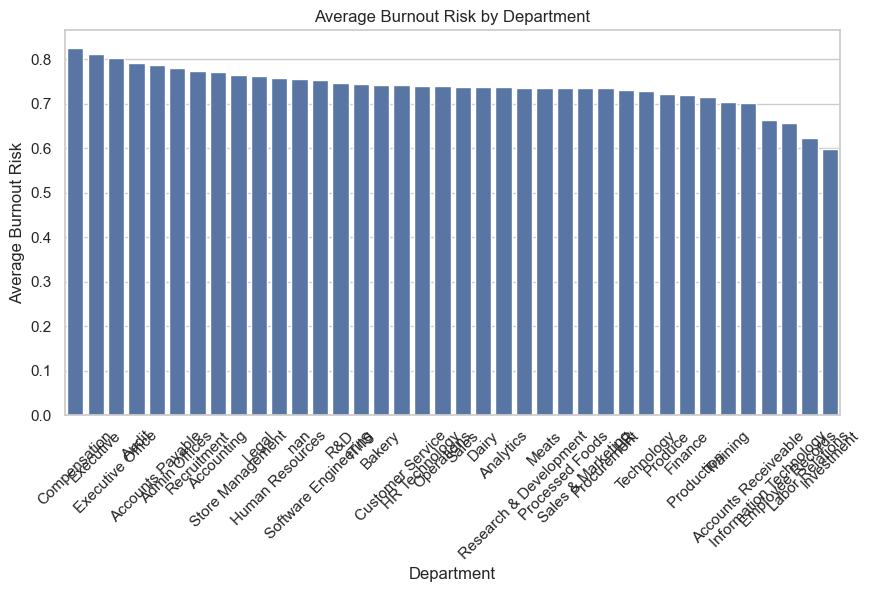

In [23]:
dept_burnout = df_all.groupby("department")["burnout_risk"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=dept_burnout.index, y=dept_burnout.values)
plt.title("Average Burnout Risk by Department")
plt.xlabel("Department")
plt.ylabel("Average Burnout Risk")
plt.xticks(rotation=45)
plt.show()

>#### Burnout levels vary by department, indicating that workplace pressure may differ depending on the nature of the department.

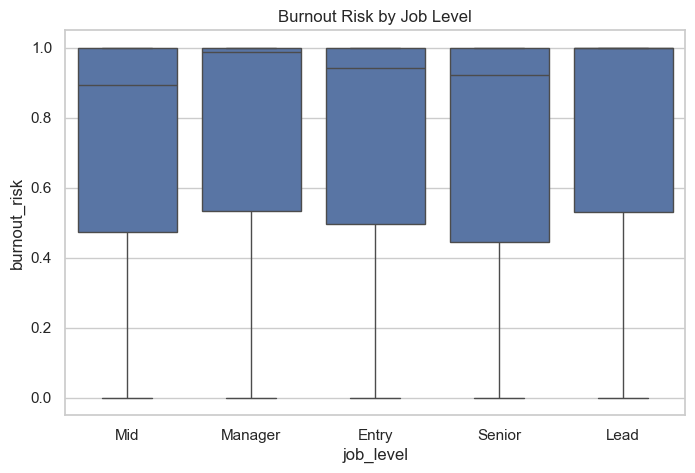

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="job_level", y="burnout_risk", data=df_all)
plt.title("Burnout Risk by Job Level")
plt.show()

>#### Burnout risk differs across job levels, suggesting that seniority or responsibility may influence employee strain.

In [25]:
important_numeric = [
    'salary',
    'satisfaction_score',
    'workload_score',
    'overtime_hours',
    'stress_level',
    'career_progression_score'
]

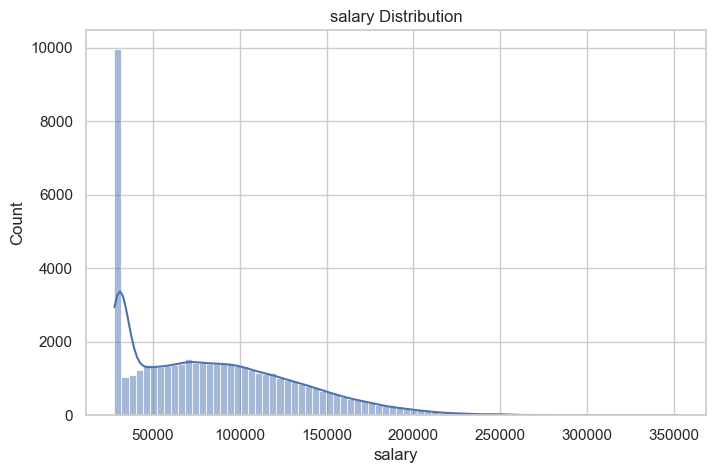

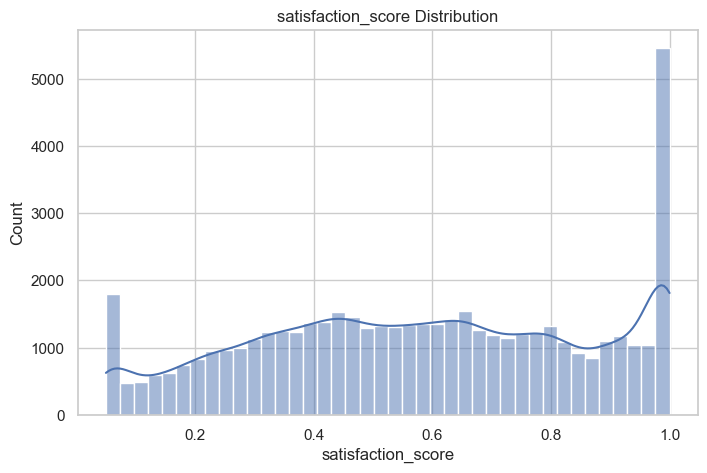

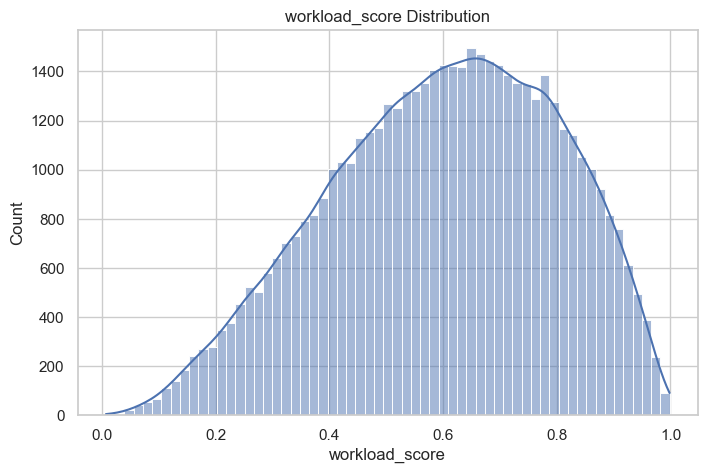

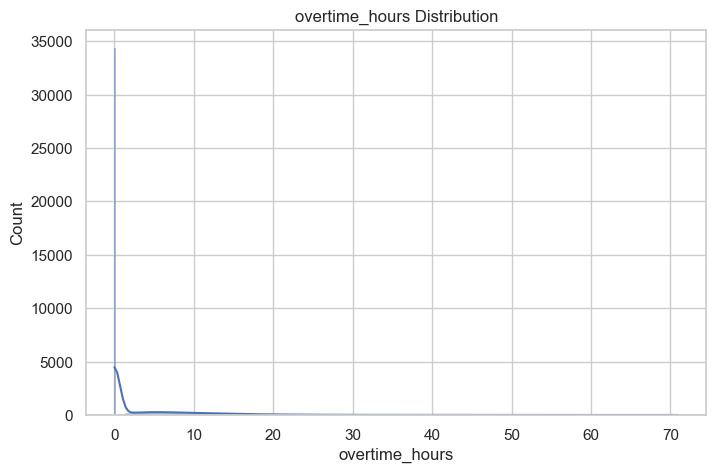

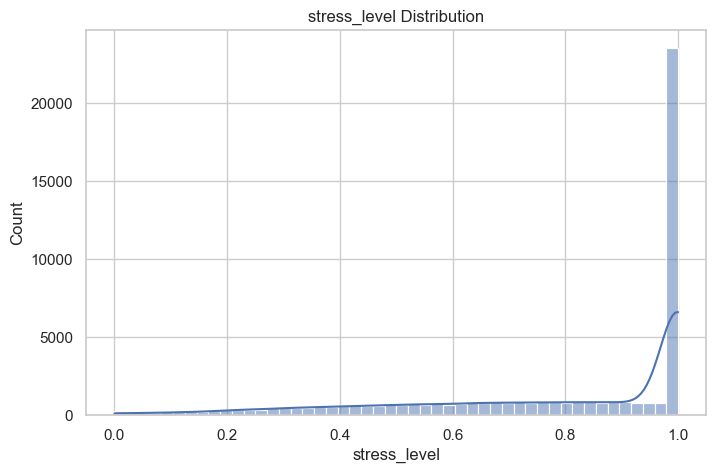

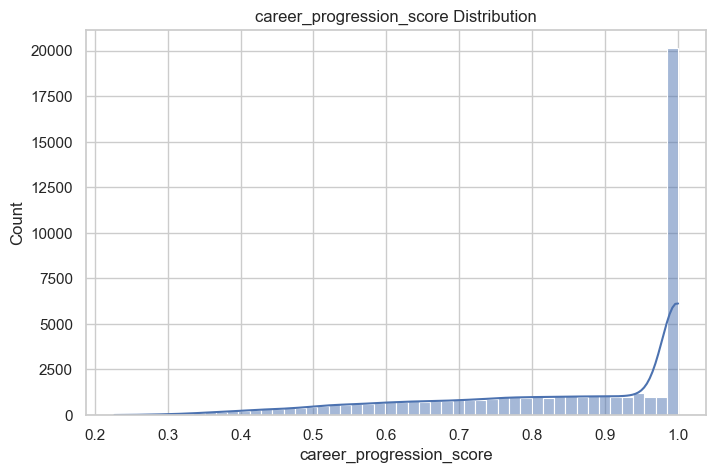

In [26]:
for col in important_numeric:
    plt.figure()
    sns.histplot(df_all[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


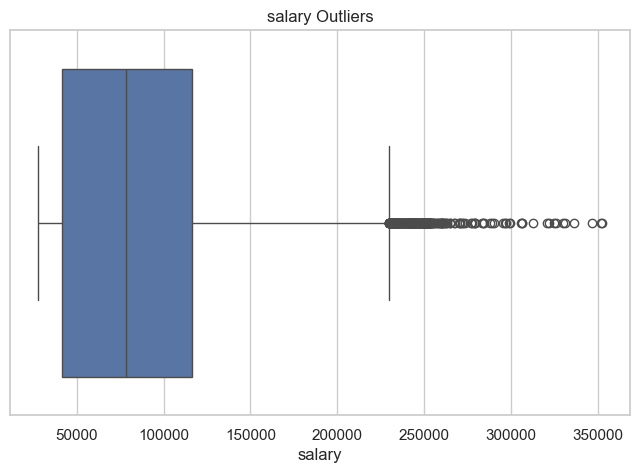

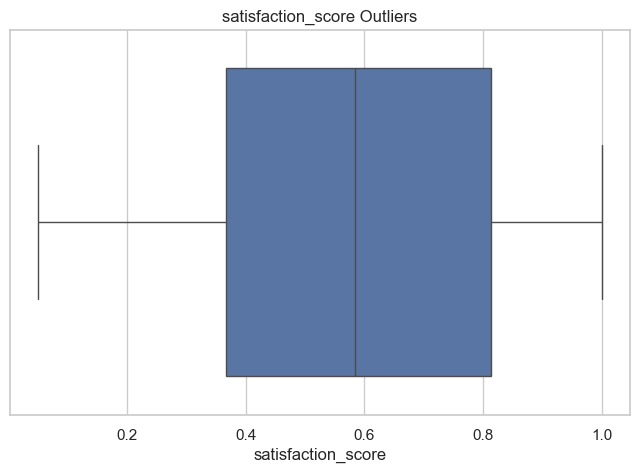

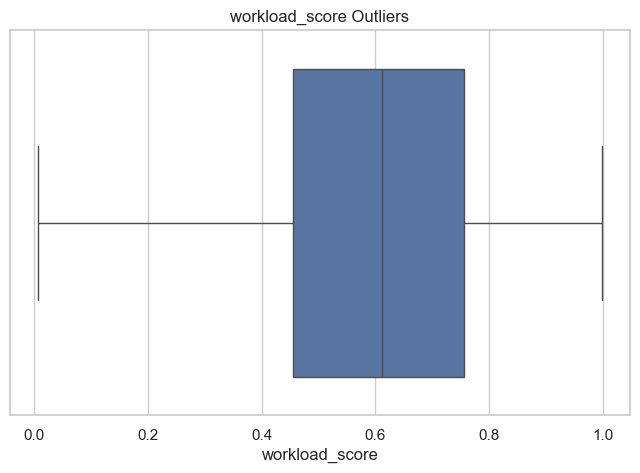

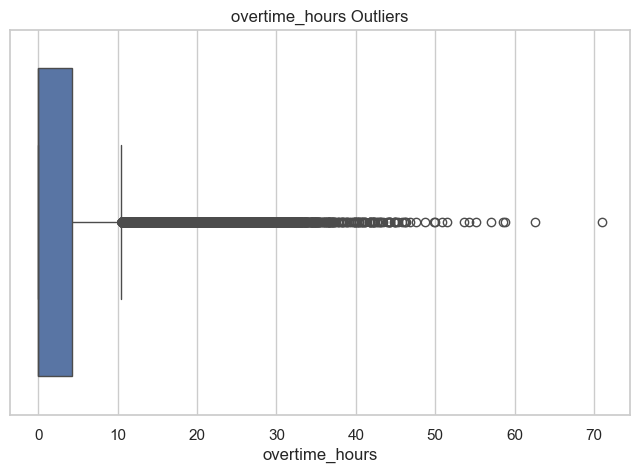

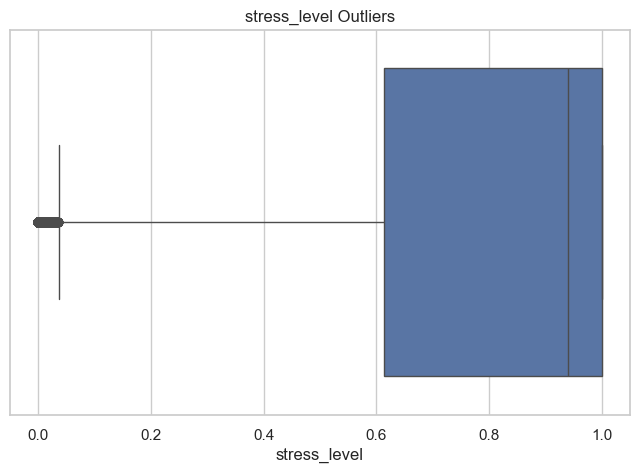

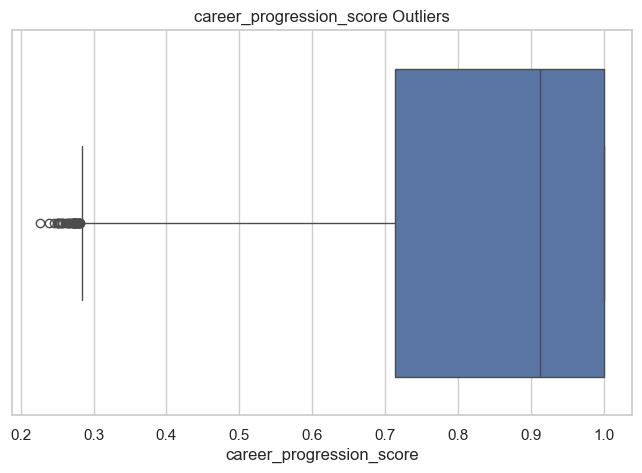

In [27]:
for col in important_numeric:
    plt.figure()
    sns.boxplot(x=df_all[col])
    plt.title(f"{col} Outliers")
    plt.show()

In [28]:
important_features = [
    'stress_level',
    'workload_score',
    'overtime_hours',
    'satisfaction_score',
    'team_sentiment',
    'project_completion_rate',
    'collaboration_score',
    'goal_achievement_rate',
    'career_progression_score',
    'role_complexity_score',
    'salary',
    'tenure_months',
    'training_participation'
]

print("\nSuggested Important Features for Model Training:")
print(important_features)



Suggested Important Features for Model Training:
['stress_level', 'workload_score', 'overtime_hours', 'satisfaction_score', 'team_sentiment', 'project_completion_rate', 'collaboration_score', 'goal_achievement_rate', 'career_progression_score', 'role_complexity_score', 'salary', 'tenure_months', 'training_participation']


In [29]:
print("\n================ FINAL INSIGHTS ================")
print("1. Higher stress_level, workload_score, and overtime_hours are expected to increase burnout risk.")
print("2. Higher satisfaction_score, team_sentiment, collaboration_score, and career_progression_score are expected to reduce burnout risk.")
print("3. Employees with higher burnout_risk are more likely to leave the company.")
print("4. Department and job_level may show differences in burnout and turnover patterns.")
print("5. The selected important_features can be used later for model training.")


================ FINAL INSIGHTS ================
1. Higher stress_level, workload_score, and overtime_hours are expected to increase burnout risk.
2. Higher satisfaction_score, team_sentiment, collaboration_score, and career_progression_score are expected to reduce burnout risk.
3. Employees with higher burnout_risk are more likely to leave the company.
4. Department and job_level may show differences in burnout and turnover patterns.
5. The selected important_features can be used later for model training.


# Phase Three: Data Refinement & Feature Engineering

## Overview:
In this phase, we transition from data discovery to data preparation. Our goal is to refine the dataset by addressing multi-collinearity, encoding categorical variables into a machine-readable format, and scaling numerical features. This ensures that our predictive models can process the information efficiently without bias or data leakage.

## Key Objectives:
- **Feature Pruning (Leakage Prevention):** Eliminating highly correlated features (like **stress_level**) that could artificially inflate model performance.

- **Categorical Encoding:** Converting the role column into numerical values using Target Encoding to manage **300**+ unique job titles without memory overhead.

- **Feature Scaling:** Normalizing numerical ranges using StandardScaler to bring features with different units (**hours** vs. **scores**) into a comparable scale.

### features select

In [30]:
# Identifying the features selected + the Target (burnout_risk)
selected_columns = [
    'workload_score', 'overtime_hours', 'role_complexity_score',
    'stress_level', 'satisfaction_score', 'team_sentiment',
    'career_progression_score', 'goal_achievement_rate',
    'meeting_participation', 'role', 'burnout_risk'
]

In [31]:
# Filtering the data to only the selected columns
BO_data = df_all[selected_columns].copy()

In [32]:
# Renaming burnout_risk to burnout_score
BO_data.rename(columns={'burnout_risk': 'burnout_score'}, inplace=True)

In [33]:
# 1. Dropping High-Leakage Features
BO_data.drop(columns=['stress_level'], inplace=True)

In [34]:
BO_data.head()

,workload_score,overtime_hours,role_complexity_score,satisfaction_score,team_sentiment,career_progression_score,goal_achievement_rate,meeting_participation,role,burnout_score
0,0.758117,0.00000,0.2,0.623746,0.662335,1.000000,0.632482,0.492131,,0.866643
1,0.788416,0.00000,0.2,0.982556,0.934661,1.000000,0.538587,0.981394,Customer Success Manager,0.218996
2,0.697617,0.00000,0.2,0.767200,0.888559,0.836495,0.624656,0.701138,Administrative Assistant,0.541531
3,0.493143,9.59168,0.2,0.185888,0.732189,1.000000,0.959320,0.339626,Senior Manager,1.000000
4,0.567230,0.00000,0.2,0.566706,0.817545,1.000000,0.677305,0.565582,Anonymous Employee,0.614825


In [35]:
# 2. Handling Categorical Variables (Target Encoding for 'role')
# Since 'role' has 300+ unique values, One-Hot Encoding is too heavy.
# We use the mean of the target for each role.
role_target_mean = BO_data.groupby('role')['burnout_score'].mean()
BO_data['role_encoded'] = BO_data['role'].map(role_target_mean)

In [36]:
# Drop the original categorical 'role' column
BO_data.drop(columns=['role'], inplace=True)

### Feature Engineering:

In [37]:
# Question: How does job difficulty and Workeload combine to create mental strain?
# Pressure Index: High score indicates a high risk of exhaustion due to complex tasks plus heavy workload
BO_data['pressure_index'] = BO_data['role_complexity_score'] * BO_data['workload_score']

In [38]:
# Question: What is the relationship between overtime hours and  satisfaction?
# Burnout Propensity: High score means the employee is working overtime but has low satisfaction
BO_data['burnout_propensity'] = BO_data['overtime_hours'] / (BO_data['satisfaction_score'] + 0.1)

In [39]:
# Question: Is the employee extra effort actually leading to results?
# Effort Efficiency: Low score indicates that overtime hours are NOT translating into goal achievement.
BO_data['effort_efficiency'] = BO_data['goal_achievement_rate'] / (BO_data['overtime_hours'] + 1)

In [40]:
# High workload with low satisfaction leads to burnout
BO_data['burnout_pressure'] = BO_data['workload_score'] / (BO_data['satisfaction_score'] + 0.1)

In [41]:
# Question: Does the team environment protect the employee from work pressure?
BO_data['culture_shield'] = BO_data['team_sentiment'] * BO_data['satisfaction_score']

### Final Dataset Structuring:

In [42]:
# Delete outliers
BO_data.replace([np.inf, -np.inf], np.nan, inplace=True)
BO_data.dropna(inplace=True)

In [43]:
# Reordering columns to place the Target (burnout_score) at the very end.
cols = [c for c in BO_data.columns if c != 'burnout_score'] + ['burnout_score']
BO_data = BO_data[cols]

In [44]:
BO_data.head()

,workload_score,overtime_hours,role_complexity_score,satisfaction_score,team_sentiment,career_progression_score,goal_achievement_rate,meeting_participation,role_encoded,pressure_index,burnout_propensity,effort_efficiency,burnout_pressure,culture_shield,burnout_score
0,0.758117,0.00000,0.2,0.623746,0.662335,1.000000,0.632482,0.492131,0.728042,0.151623,0.00000,0.632482,1.047490,0.413129,0.866643
1,0.788416,0.00000,0.2,0.982556,0.934661,1.000000,0.538587,0.981394,0.801505,0.157683,0.00000,0.538587,0.728291,0.918357,0.218996
2,0.697617,0.00000,0.2,0.767200,0.888559,0.836495,0.624656,0.701138,0.738434,0.139523,0.00000,0.624656,0.804447,0.681703,0.541531
3,0.493143,9.59168,0.2,0.185888,0.732189,1.000000,0.959320,0.339626,0.754319,0.098629,33.55045,0.090573,1.724950,0.136105,1.000000
4,0.567230,0.00000,0.2,0.566706,0.817545,1.000000,0.677305,0.565582,0.722064,0.113446,0.00000,0.677305,0.850794,0.463308,0.614825


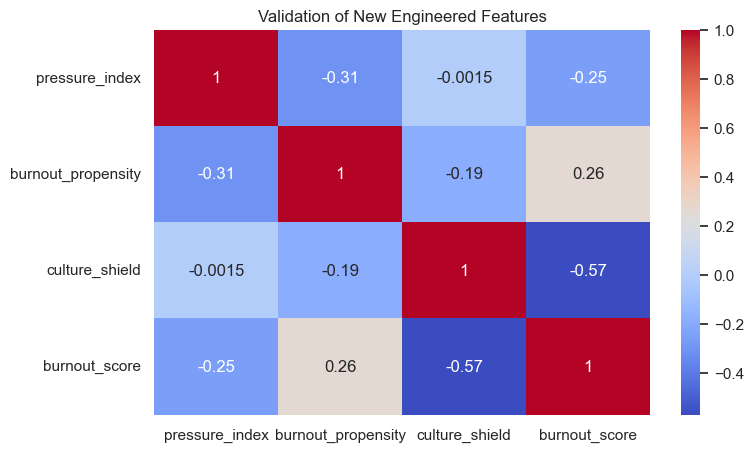

In [45]:
new_features_corr = BO_data[['pressure_index', 'burnout_propensity', 'culture_shield', 'burnout_score']].corr()
sns.heatmap(new_features_corr, annot=True, cmap='coolwarm')
plt.title("Validation of New Engineered Features")
plt.show()

### Insight:

- A positive correlation of 0.26 validates that employees who endure high overtime with minimal emotional returns are significantly more susceptible to burnout.

- With a strong negative correlation of -0.57, the Culture Shield acts as the most powerful defense mechanism, proving that high team sentiment and job satisfaction drastically neutralize burnout risk.

- The unexpected negative correlation of -0.25 suggests that high-complexity roles in this dataset may benefit from superior support systems or higher engagement, mitigating strain compared to high-volume routine tasks.

In [46]:
#save data.csv as a file
BO_data.to_csv('Data/Clean_data.csv', index=False)

# Phase Four: Model training, Selection and Evaluation

## Overview:


## Key Objectives:


In [47]:
# Load data
df = pd.read_csv('Data/Clean_data.csv')
display(df.head())

# 1. Define Features (X) and Target (y)
X = df.drop(columns=['burnout_score'])
y = df['burnout_score']

# 2. Train/Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

# 3. Feature Scaling
# Tree-based models don't strictly require scaling, but Linear Regression does.
# It's best practice to scale for a fair comparison.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Global list to store model performance
model_performance = []

# 5. Helper function for consistent evaluation
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"--- {model_name} Performance ---")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}\n")

    model_performance.append({
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })

,workload_score,overtime_hours,role_complexity_score,satisfaction_score,team_sentiment,career_progression_score,goal_achievement_rate,meeting_participation,role_encoded,pressure_index,burnout_propensity,effort_efficiency,burnout_pressure,culture_shield,burnout_score
0,0.758117,0.00000,0.2,0.623746,0.662335,1.000000,0.632482,0.492131,0.728042,0.151623,0.00000,0.632482,1.047490,0.413129,0.866643
1,0.788416,0.00000,0.2,0.982556,0.934661,1.000000,0.538587,0.981394,0.801505,0.157683,0.00000,0.538587,0.728291,0.918357,0.218996
2,0.697617,0.00000,0.2,0.767200,0.888559,0.836495,0.624656,0.701138,0.738434,0.139523,0.00000,0.624656,0.804447,0.681703,0.541531
3,0.493143,9.59168,0.2,0.185888,0.732189,1.000000,0.959320,0.339626,0.754319,0.098629,33.55045,0.090573,1.724950,0.136105,1.000000
4,0.567230,0.00000,0.2,0.566706,0.817545,1.000000,0.677305,0.565582,0.722064,0.113446,0.00000,0.677305,0.850794,0.463308,0.614825


(40000, 14)
(10000, 14)


### Baseline model: Linear Regression


In [48]:
# Initialize and train
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [49]:
# Predict and Evaluate
lr_preds = lr_model.predict(X_test_scaled)
evaluate_model("Linear Regression", y_test, lr_preds)

--- Linear Regression Performance ---
MAE:  0.1490
RMSE: 0.1838
R²:   0.6561



### Model 1: Random Forest

In [50]:
# Initialize and train
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)


RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

In [51]:
# Predict and Evaluate
rf_preds = rf_model.predict(X_test_scaled)
evaluate_model("Random Forest", y_test, rf_preds)

--- Random Forest Performance ---
MAE:  0.1012
RMSE: 0.1503
R²:   0.7699



### Model 2: XGBoost

In [52]:
# Initialize and train
xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=7, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [53]:

# Predict and Evaluate
xgb_preds = xgb_model.predict(X_test_scaled)
evaluate_model("XGBoost", y_test, xgb_preds)

--- XGBoost Performance ---
MAE:  0.1002
RMSE: 0.1493
R²:   0.7731



### Model 3: LightGBM

In [54]:
# Convert scaled arrays back to DataFrames to retain feature names
X_train_final = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_train.columns)

# Initialize and train
# lgb_model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=7, random_state=42, n_jobs=-1)
# lgb_model.fit(X_train_final, y_train)

##############################################################################


# 1. Define the base model
# We remove the hyper-parameters here so the grid search can inject them.
lgb_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1)

# 2. Define the parameter grid
# Note: In LightGBM, 'num_leaves' is often more important than 'max_depth'. 
# Rule of thumb: num_leaves should be <= 2^(max_depth).
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [5, 7],
    'num_leaves': [31, 63] 
}

# 3. Setup GridSearchCV
# We use cv=3 to save time given the 850k rows. 
# Change 'scoring' to match whatever your evaluate_model function prioritizes (e.g., 'neg_root_mean_squared_error', 'r2')
grid_search = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error', 
    cv=3,
    verbose=2, # Set to 2 to print progress and see how long each fit takes
    n_jobs=-1  # Use all available CPU cores
)

# 4. Fit the model
print("Starting Grid Search...")
grid_search.fit(X_train_final, y_train)

# 5. Extract the best model and parameters
print(f"\nBest parameters found: {grid_search.best_params_}")
best_lgb_model = grid_search.best_estimator_


Starting Grid Search...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001537 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3374
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 14
[LightGBM] [Info] Start training from score 0.733944
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

In [55]:
# Predict and Evaluate
lgb_preds = best_lgb_model.predict(X_test_final)
evaluate_model("LightGBM (GridSearch)", y_test, lgb_preds)

--- LightGBM (GridSearch) Performance ---
MAE:  0.1001
RMSE: 0.1479
R²:   0.7773



## Stacking

In [56]:
# 1. Define the base models (using the tuned models from your previous cells)
estimators = [
    ('rf', rf_model),
    ('xgb', xgb_model),
    ('lgb', best_lgb_model)
]

# 2. Initialize the Stacking Regressor
# We use Linear Regression as the meta-model to find the optimal weights for each base model's predictions
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression(),
    cv=3,          # Number of cross-validation folds for training the meta-model
    n_jobs=-1      # Use all CPU cores
)

# 3. Train the Stacking Model
stacking_model.fit(X_train_final, y_train)


StackingRegressor(cv=3,
                  estimators=[('rf',
                               RandomForestRegressor(max_depth=10, n_jobs=-1,
                                                     random_state=42)),
                              ('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights...
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=7,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=-1,
                                            num_parallel_tree=None, ...)),
                              ('lgb',
                               LGBMRegressor(learning_rate=0.05, max_depth=7,
                                             n_estimators=300, n_jobs=-1,
                                             random_state=42))],
                  final_estimator=LinearRegression(), n_jobs=-1)

In [57]:
# Predict and Evaluate
stacking_preds = stacking_model.predict(X_test_final)
evaluate_model("Stacking Regressor", y_test, stacking_preds)

--- Stacking Regressor Performance ---
MAE:  0.0998
RMSE: 0.1476
R²:   0.7781



# Final Results

,Model,MAE,RMSE,R²
0,Stacking Regressor,0.099776,0.147623,0.778071
1,LightGBM (GridSearch),0.100120,0.147884,0.777287
2,XGBoost,0.100242,0.149273,0.773083
3,Random Forest,0.101163,0.150311,0.769915
4,Linear Regression,0.148963,0.183777,0.656057


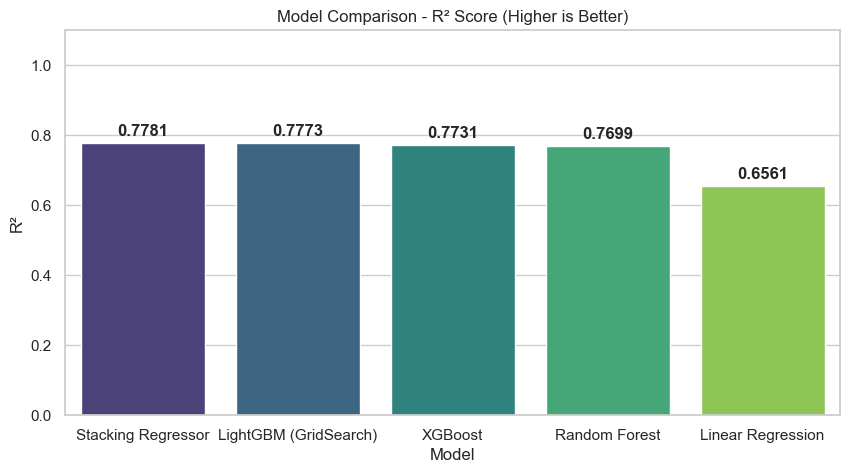

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001695 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3348
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 14
[LightGBM] [Info] Start training from score 0.733944
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


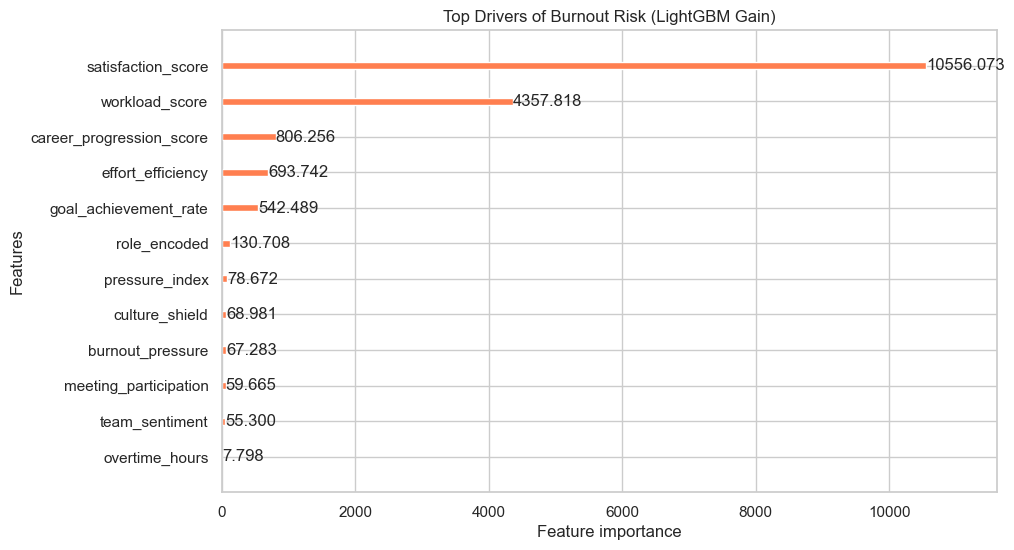

In [58]:
# Convert performance dictionary to DataFrame
results_df = pd.DataFrame(model_performance)

# Sort by R² (Highest is best)
results_df = results_df.sort_values(by='R²', ascending=False).reset_index(drop=True)
display(results_df)

# Plotting the Comparison
plt.figure(figsize=(10, 5))
# sns.barplot(x='Model', y='R²', data=results_df, palette='viridis')
sns.barplot(x='Model', y='R²', data=results_df, hue='Model', palette='viridis', legend=False)
plt.title('Model Comparison - R² Score (Higher is Better)')
plt.ylim(0, 1.1)
for i, v in enumerate(results_df['R²']):
    plt.text(i, v + 0.02, str(round(v, 4)), ha='center', fontweight='bold')
plt.show()

# Plotting Feature Importance from LightGBM (Top performing)
# Note: Re-training LightGBM without scaling for interpretable feature importance
lgb_interpret = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=7, random_state=42, n_jobs=-1)
lgb_interpret.fit(X_train, y_train)

lgb.plot_importance(lgb_interpret, max_num_features=12, importance_type='gain',
                    figsize=(10, 6), title='Top Drivers of Burnout Risk (LightGBM Gain)',
                    color='coral')
plt.show()